In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

use_cuda = True 

#device = torch.device("cuda") if use_cuda and torch.cuda.is_available() else torch.device("cpu")
device = torch.device("cuda")
print(f"Using device: {device}")

Using device: cuda


In [6]:
def voxel_downsampling(
        points: torch.Tensor,  # only pass points before a certain distance
        voxel_size: float,
        mode:str ="first"
):

    points = points.to(device)

    if points.numel() == 0:
        return points
        
    s = max(float(voxel_size),1e-6)
    q = torch.floor(points/s).to(torch.int32)

    key = (q[:, 0].to(torch.int64) * 73856093) ^ \
          (q[:, 1].to(torch.int64) * 19349663) ^ \
          (q[:, 2].to(torch.int64) * 83492791)

    uniq,inv = torch.unique(key,return_inverse=True)
    inv = inv.to(device)

    V = uniq.numel()
    D = points.shape[1]
    N = points.shape[0]


    if mode == "centroid": 
        sums = torch.zeros((V,D), device = device, dtype=points.dtype)
        counts = torch.zeros((V,1), device = device, dtype=points.dtype)
        sums.index_add_(0, inv, points)
        ones = torch.ones((points.shape[0],1), device=device,dtype=points.dtype)
        counts.index_add_(0,inv,ones)

        centroids = sums/counts
        return centroids 

    if mode == "first":
        idx = torch.arange(N,device=device,dtype=torch.int64)
        first = torch.full((V,),N, device=device)
        first = first.scatter_reduce(0,inv,idx,reduce="amin",include_self=True)
        return points[first]

Using device: cuda
Original points: torch.Size([200000, 3])
After FIRST: torch.Size([10000, 3])
After CENTROID: torch.Size([10000, 3])


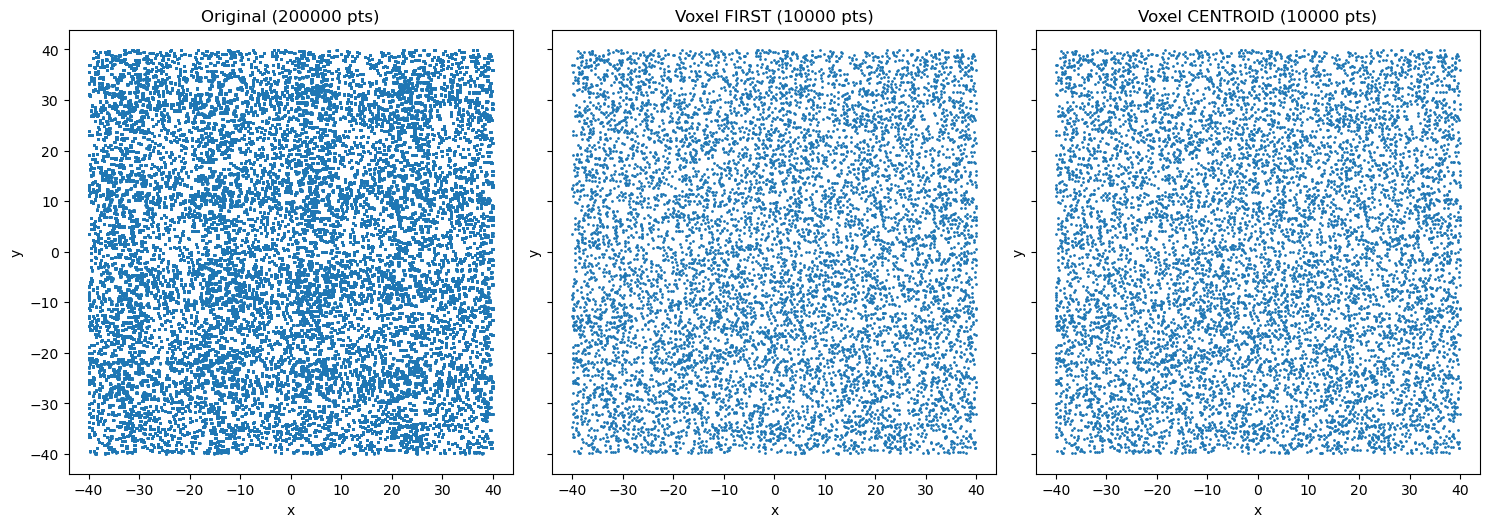

In [14]:
# -----------------------------
# Device (force CUDA)
# -----------------------------
assert torch.cuda.is_available(), "CUDA not available"
device = "cuda"
print("Using device:", device)

# -----------------------------
# Synthetic test data generator
# -----------------------------
def make_test_points(N=2000, voxel_size=0.2, dup_factor=20, device="cuda", seed=42):
    torch.manual_seed(seed)
    V = max(1000, N // dup_factor)

    # Random voxel coordinates
    q = torch.randint(low=-200, high=200, size=(V, 3), device=device)

    # Voxel centers
    centers = q.to(torch.float32) * voxel_size + 0.5 * voxel_size

    # Pick voxels and add small jitter inside voxel
    pick = torch.randint(0, V, size=(N,), device=device)
    jitter = (torch.rand((N,3), device=device) - 0.5) * (0.49 * voxel_size)

    return centers[pick] + jitter


# -----------------------------
# Generate points
# -----------------------------
voxel = 0.2
points = make_test_points(
    N=200000,
    voxel_size=voxel,
    dup_factor=20,
    device=device
)

print("Original points:", points.shape)

# -----------------------------
# Downsample
# -----------------------------
points_first = voxel_downsampling(points, voxel, mode="first")
points_cent  = voxel_downsampling(points, voxel, mode="centroid")

print("After FIRST:", points_first.shape)
print("After CENTROID:", points_cent.shape)

# -----------------------------
# Move to CPU for plotting
# -----------------------------
pts_cpu   = points[:, :2].detach().cpu()
first_cpu = points_first[:, :2].detach().cpu()
cent_cpu  = points_cent[:, :2].detach().cpu()

# -----------------------------
# Plot (XY view)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(pts_cpu[:,0], pts_cpu[:,1], s=1)
axes[0].set_title(f"Original ({pts_cpu.shape[0]} pts)")

axes[1].scatter(first_cpu[:,0], first_cpu[:,1], s=1)
axes[1].set_title(f"Voxel FIRST ({first_cpu.shape[0]} pts)")

axes[2].scatter(cent_cpu[:,0], cent_cpu[:,1], s=1)
axes[2].set_title(f"Voxel CENTROID ({cent_cpu.shape[0]} pts)")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()